### Imports

In [56]:
import time
from itertools import combinations
from ucimlrepo import fetch_ucirepo 

import pandas as pd
import matplotlib.pyplot as plt

### Data Processing

In [6]:
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 

In [7]:
dataset = online_retail.data

In [8]:
df = dataset["original"]

In [9]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [10]:
len(df["InvoiceNo"].unique())

25900

In [11]:
len(df["Description"].unique())

4224

## Fequent Itemset Mining

**What it does**: Solves the first step of **association rule mining** by finding all itemsets that appear frequently in the dataset

### Naive/Brute Force
**What it does:**
1. Collect all items in the dataset
2. Generate all possible itemsets (power set)
3. Compute support for each itemset
4. Keep only those above minsup

**Complexity:** $O(2^{|I|}\cdot|I|\cdot|T|)$

In [37]:
# The dataset is a list of transactions, where each transaction is a set of items


### DUMMY TRANSACTIONS
# transactions = [
#     {"milk", "tea", "yoghurt"},
#     {"milk", "oats"},
#     {"milk", "biscuits", "tea"},
#     {"muesli", "yoghurt"},
#     {"oats", "milk", "tea"},
#     {"muesli", "milk", "tea"}
# ]

N_ITEMS = 10

top_items = (
  df["Description"]
  .value_counts()
  .head(N_ITEMS)
  .index
)

df_small = df[df["Description"].isin(top_items)]

transactions = (
  df_small.groupby("InvoiceNo")["Description"]
  .apply(set)
  .tolist()
)


In [72]:
len(transactions)

11215

In [38]:
transactions

[{'WHITE HANGING HEART T-LIGHT HOLDER'},
 {'ASSORTED COLOUR BIRD ORNAMENT'},
 {'WHITE HANGING HEART T-LIGHT HOLDER'},
 {'WHITE HANGING HEART T-LIGHT HOLDER'},
 {'LUNCH BAG RED RETROSPOT', 'PACK OF 72 RETROSPOT CAKE CASES'},
 {'NATURAL SLATE HEART CHALKBOARD '},
 {'JUMBO BAG RED RETROSPOT'},
 {'JUMBO BAG RED RETROSPOT', 'WHITE HANGING HEART T-LIGHT HOLDER'},
 {'ASSORTED COLOUR BIRD ORNAMENT'},
 {'WHITE HANGING HEART T-LIGHT HOLDER'},
 {'ASSORTED COLOUR BIRD ORNAMENT', 'PACK OF 72 RETROSPOT CAKE CASES'},
 {'WHITE HANGING HEART T-LIGHT HOLDER'},
 {'LUNCH BAG RED RETROSPOT', 'WHITE HANGING HEART T-LIGHT HOLDER'},
 {'LUNCH BAG  BLACK SKULL.', 'PACK OF 72 RETROSPOT CAKE CASES'},
 {'WHITE HANGING HEART T-LIGHT HOLDER'},
 {'ASSORTED COLOUR BIRD ORNAMENT', 'PACK OF 72 RETROSPOT CAKE CASES'},
 {'JUMBO BAG RED RETROSPOT'},
 {'LUNCH BAG  BLACK SKULL.', 'LUNCH BAG RED RETROSPOT'},
 {'PACK OF 72 RETROSPOT CAKE CASES'},
 {'ASSORTED COLOUR BIRD ORNAMENT'},
 {'ASSORTED COLOUR BIRD ORNAMENT',
  'JUMBO B

In [39]:
# Extract the set of all items

def get_items(transactions):
  items = set()
  for t in transactions:
    items.update(t)
  return items

In [40]:
items = get_items(transactions)

In [41]:
print(len(items))
print(items)

10
{'LUNCH BAG  BLACK SKULL.', 'REGENCY CAKESTAND 3 TIER', 'PACK OF 72 RETROSPOT CAKE CASES', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT', 'SET OF 3 CAKE TINS PANTRY DESIGN ', 'PARTY BUNTING', 'WHITE HANGING HEART T-LIGHT HOLDER', 'LUNCH BAG RED RETROSPOT', 'NATURAL SLATE HEART CHALKBOARD '}


In [42]:
# Generate Power Set

def generate_itemsets(items):
  items = list(items)

  for k in range(1, len(items) + 1):
    for combo in combinations(items, k):
      yield set(combo)

In [43]:
itemsets = generate_itemsets(items)

In [44]:
itemsets

<generator object generate_itemsets at 0x0000026D8BFA6DC0>

Compute Support

The support counts how many transactions contain the itemset.

$support(X)=|\{t\in T: X\sube t\}$

In [45]:
def compute_support(itemset, transactions):
  count = 0

  for transaction in transactions:
    if itemset.issubset(transaction):
      count += 1
  
  return count

In [46]:
support_test = compute_support({"WHITE HANGING HEART T-LIGHT HOLDER"}, transactions)
support_test

2302

In [47]:
# Implement the Naive Mining Algorithm

def naive_frequent_itemsets(transactions, minsup):
  items = get_items(transactions)

  frequent_itemsets = []

  for itemset in generate_itemsets(items):

    support = compute_support(itemset, transactions)

    if support >= minsup:
      frequent_itemsets.append((itemset, support))

  return frequent_itemsets

In [48]:
start = time.time()

minsup = 1000

frequent_sets = sorted(naive_frequent_itemsets(transactions, minsup), key=lambda x: x[1], reverse=True)

end = time.time()

print("Execution time:", end-start)

print("Frequent sets:")
for itemset, support in frequent_sets:
  print(itemset, support)

Execution time: 0.5802063941955566
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169
{'JUMBO BAG RED RETROSPOT'} 2135
{'PARTY BUNTING'} 1706
{'LUNCH BAG RED RETROSPOT'} 1607
{'ASSORTED COLOUR BIRD ORNAMENT'} 1467
{'SET OF 3 CAKE TINS PANTRY DESIGN '} 1458
{'PACK OF 72 RETROSPOT CAKE CASES'} 1334
{'LUNCH BAG  BLACK SKULL.'} 1295
{'NATURAL SLATE HEART CHALKBOARD '} 1266


In [55]:
run_times_naive = []
for n_items in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
  top_items = (
    df["Description"]
    .value_counts()
    .head(n_items)
    .index
  )

  df_small = df[df["Description"].isin(top_items)]

  transactions = (
    df_small.groupby("InvoiceNo")["Description"]
    .apply(set)
    .tolist()
  )

  start = time.time()

  minsup = 1000

  frequent_sets = naive_frequent_itemsets(transactions, minsup)
  frequent_sets.sort(key=lambda x: x[1], reverse=True)

  end = time.time()

  run_times_naive.append((n_items, end-start))

  print(f"\n===== n_items = {n_items} =====")

  print("Execution time:", end-start)

  print(f"Frequent sets:")
  for itemset, support in frequent_sets:
    print(itemset, support)



===== n_items = 1 =====
Execution time: 0.012541770935058594
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302

===== n_items = 2 =====
Execution time: 0.0034286975860595703
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169

===== n_items = 3 =====
Execution time: 0.01072239875793457
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169
{'JUMBO BAG RED RETROSPOT'} 2135

===== n_items = 4 =====
Execution time: 0.013660907745361328
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169
{'JUMBO BAG RED RETROSPOT'} 2135
{'PARTY BUNTING'} 1706

===== n_items = 5 =====
Execution time: 0.045363426208496094
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169
{'JUMBO BAG RED RETROSPOT'} 2135
{'PARTY BUNTING'} 1706
{'LUNCH BAG RED RETROSPOT'} 1607

===== n_items = 6 =====
Execution time: 0.10155963897705078
Frequent sets:
{'WHI

In [62]:
run_times_naive

[(1, 0.012541770935058594),
 (2, 0.0034286975860595703),
 (3, 0.01072239875793457),
 (4, 0.013660907745361328),
 (5, 0.045363426208496094),
 (6, 0.10155963897705078),
 (7, 0.1399240493774414),
 (8, 0.45963239669799805),
 (9, 0.6275794506072998),
 (10, 1.5648353099822998),
 (11, 3.028953790664673),
 (12, 6.643423318862915),
 (13, 13.49615740776062),
 (14, 30.465193271636963),
 (15, 57.27067160606384)]

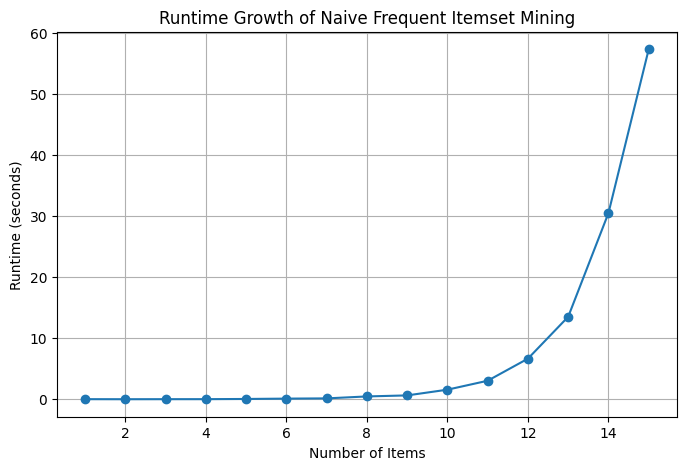

In [71]:
import matplotlib.pyplot as plt

num_items, run_times = zip(*run_times_naive)

plt.figure(figsize=(8,5))
plt.plot(num_items, run_times, marker="o")

plt.xlabel("Number of Items")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Growth of Naive Frequent Itemset Mining")
plt.grid(True)

plt.show()

### Apriori